#### Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#https://colab.research.google.com/github/google-deepmind/alphaevolve_results/blob/master/mathematical_results.ipynb#scrollTo=rvd1otTRMjjn)

def plot_step_function(step_heights_input: list[float]):
  num_steps = len(step_heights_input)

  # Generate x values for plotting (need to plot steps properly).
  step_edges_plot = np.linspace(-0.25, 0.25, num_steps + 1)
  x_plot = np.array([])
  y_plot = np.array([])

  for i in range(num_steps):
    x_start = step_edges_plot[i]
    x_end = step_edges_plot[i + 1]
    x_step_vals = np.linspace(x_start, x_end, 100)  # Points within each step.
    y_step_vals = np.full_like(x_step_vals, step_heights_input[i])
    x_plot = np.concatenate((x_plot, x_step_vals))
    y_plot = np.concatenate((y_plot, y_step_vals))

  # Plot the step function.
  plt.figure(figsize=(8, 5))
  plt.plot(x_plot, y_plot)
  plt.xlabel("x")
  plt.ylabel("f(x)")
  plt.title(
      "Step function found by AlphaEvolve for Erdős' minimum overlap problem"
  )
  plt.xlim([-0.3, 0.3])
  plt.ylim([-1, max(step_heights_input) * 1.2])
  plt.grid(True)
  plt.step(
      step_edges_plot[:-1],
      step_heights_input,
      where='post',
      color='green',
      linewidth=2,
  )  # Overlay with plt.step for clarity.
  plt.show()

In [2]:
def select_folder_path(folder_path: str):
  """Adds the folder path to sys.path if it's not already there."""
  import sys
  import os

  if folder_path not in sys.path:
      sys.path.append(folder_path)

In [3]:
import json

def load_json(json_path: str) -> list[float]:
    """Loads the sequence from a JSON file."""
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

#### Run the evolved function

In [ ]:
# folder_path = "/home/guests2/vic/work/projects/phd/R2/evolve/shinka_evolve/ShinkaEvolve/results/alpha_evolve_math_problems/second_autocorr_ineq/2026.03.03160427_alpha_evolve_w_evaluator_large/best/"
# select_folder_path(folder_path)

# # Import and fetch the function - ensure the function name matches the one in your main.py
# from main import run

# sequence = run()

In [6]:
json_path = "/home/guests2/vic/work/projects/phd/R2/evolve/shinka_evolve/ShinkaEvolve/results/alpha_evolve_math_problems/third_autocorr_ineq/2026.03.04131536_open_evolve/best/results/metrics.json"

json_content = load_json(json_path)
best_sequence = json_content["best_sequence"]
best_c3 = json_content["best_c3"]
print(f"The discovered step function shows C3 <= {best_c3}.")
convolution = np.convolve(best_sequence, best_sequence)

The discovered step function shows C3 <= 1.4858096230085842.


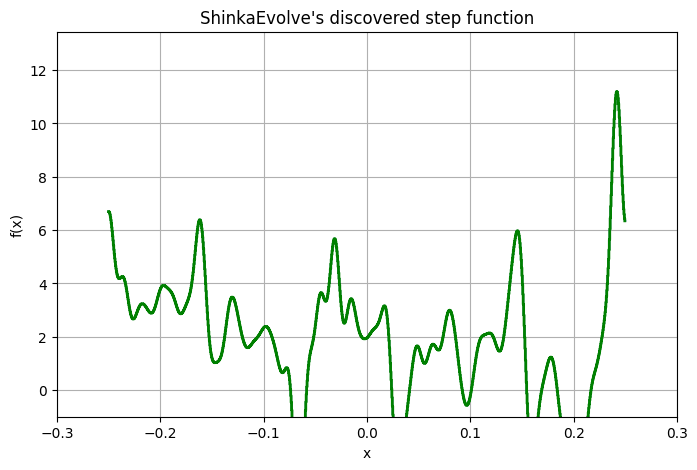

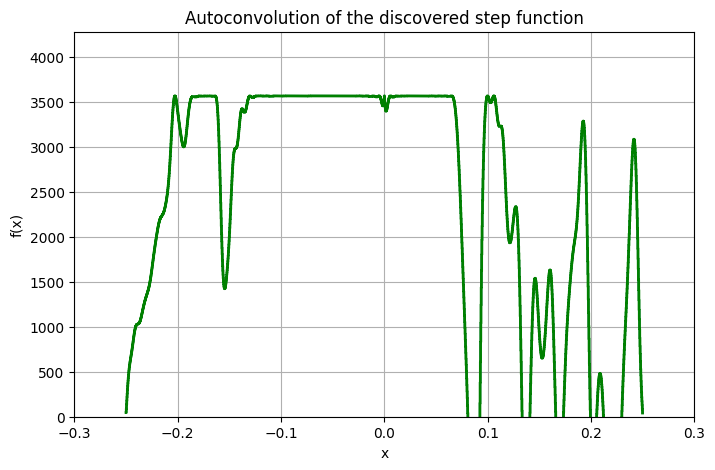

In [7]:
plot_step_function(best_sequence, title="ShinkaEvolve's discovered step function")
plot_step_function(convolution,   title="Autoconvolution of the discovered step function")

#### AlphaEvolve's solution visualization

##### AlphaEvolve's solution

In [22]:
# AlphaEvolve solution
heights_sequence_2 = [0.0022217502753395443, 0.798058737836952, 0.4369294656327977, 1.1704958412868685, 1.3413665690827143, 1.5342366222696133, 1.7690742844401723, 1.9329450122360183, 2.2225113878900893, 1.9363966992163675, 2.0382191032475467, 2.2010898310433933, 2.0229605588392388, 2.029541518023742, 2.2636974412575626, 1.9622346498507677, 2.0781053776466134, 2.9856571697702514, 3.4418422600649374, 3.3477129878607825, 3.253250196453988, 3.420135507780267, 3.2509579118114464, 3.2308578066681575, 3.4707132763246245, 2.6462657430572087, 0.9614362498214617, 0, 0.0008733532713782356, 0.00041056186458359313, 0.00029587319086208687, 5.039012949497012e-06, 0, 0.5858888998745988, 6.741440691998236, 7.934548956206666e-06, 0.00013382382526231794, 4.551621108101551e-06, 0.0008898629473865954, 1.083008496291632e-05, 0.0006121618352774956, 0.0011493704284828532, 7.157034681754761, 9.111886252846807, 3.3127569806426527, 8.556232703271356e-06, 0.00017950056213609822, 2.7122354902710758e-06, 1.4036462843158317e-05, 1.1451768709981007e-05]

##### Visualization

In [23]:
convolution_2 = np.convolve(heights_sequence_2, heights_sequence_2)
num_points = len(convolution_2)
x_points = np.linspace(-0.5, 0.5, num_points + 2)
x_intervals = np.diff(x_points) # Width of each interval
y_points = np.concatenate(([0], convolution_2, [0]))
l2_norm_squared = 0.0
for i in range(len(convolution_2) + 1):  # Iterate through intervals
  y1 = y_points[i]
  y2 = y_points[i+1]
  h = x_intervals[i]
  # Integral of (mx + c)^2 = h/3 * (y1^2 + y1*y2 + y2^2) where m = (y2-y1)/h, c = y1 - m*x1, interval is [x1, x2], y1 = mx1+c, y2=mx2+c
  interval_l2_squared = (h / 3) * (y1**2 + y1 * y2 + y2**2)
  l2_norm_squared += interval_l2_squared

# Calculate the 1-norm: ||f*f||_1
norm_1 = np.sum(np.abs(convolution_2)) / (len(convolution_2) + 1)

# Calculate the infinity-norm: ||f*f||_inf
norm_inf = np.max(np.abs(convolution_2))
C_lower_bound = l2_norm_squared / (norm_1 * norm_inf)

print(f"This step function shows that C2 >= {C_lower_bound}")

This step function shows that C2 >= 0.8962799441554086


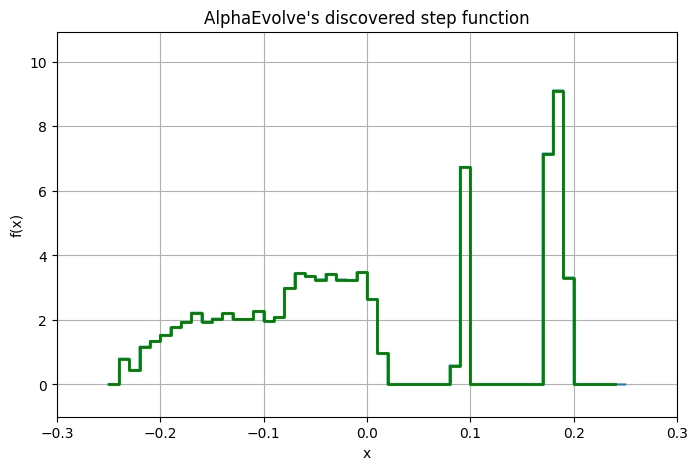

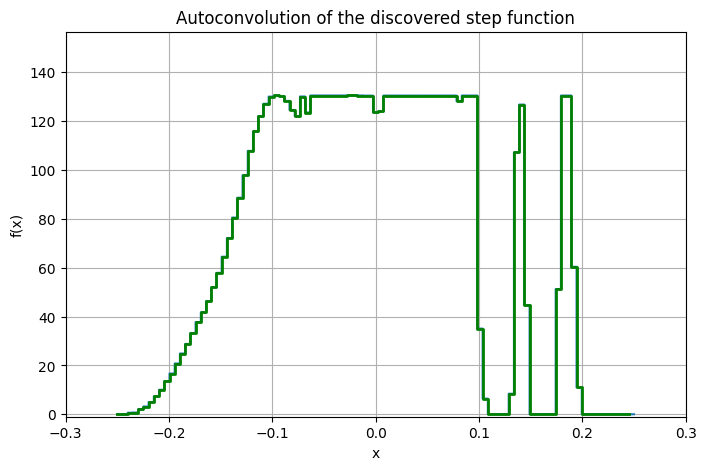

In [26]:
plot_step_function(heights_sequence_2, title="AlphaEvolve's discovered step function")
plot_step_function(convolution_2, title="Autoconvolution of the discovered step function")